In [53]:
import pandas as pd
import os
import numpy as np
from scipy.signal import correlate
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
from gensim.corpora import Dictionary
from gensim.models import LdaModel
from pprint import pprint
from nltk.corpus import stopwords
import re
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag, word_tokenize
import nltk
from collections import defaultdict

In [54]:
#Functions used in LDA

def text_split_new(text) :

    #Initialize a set of frequent and not relevent words in english
    #stop_words = set(stopwords.words('english'))

    #Remove from text all punctuations
    text = re.sub(r'[^\w\s]', '', text)
    

    #Tokenise the text in words and convert in small letters
    words = word_tokenize(text)
    
    #Filter the words depending on their grammatical class
    
    text_splited = []

    for word in words:

        #Find the grammatical class (pos) of a word and tag it with it
        pos = pos_tag([word])[0][1]
        #Keep only the nouns (singular and plural)
        if pos in ['NN', 'NNS']: #and word not in stop_words:
            text_splited.append(word)
    
    return text_splited

def bag_of_words(text_splited) : 
    
    #Create a dictionary mapping each word to a unique id
    dictionary = Dictionary([text_splited])
    
    
    corpus = dictionary.doc2bow(text_splited)
    
    return corpus, dictionary

def lda(df_line):
    corpus, dictionary = df_line  # Unpacking the tuple directly
    lda_model = LdaModel([corpus], num_topics=1, id2word=dictionary)
    return lda_model

def get_topics(lda_model):
    
    return lda_model.show_topics(num_topics=1, num_words=50, formatted=True)

def extract(topics_tuple):
    topics = []
    pattern = re.compile(r'(\d+\.\d+)\*"(.*?)"')
    for topic_id, topics_str in topics_tuple:
        matches = pattern.findall(topics_str)
        for match in matches:
            freq = float(match[0])
            word = match[1]
            topics.append((word, freq))
    return topics

In [55]:
path = "src/data/wikipedia_summaries"
summary_per_decade = [[]]
i = 0 

for folder, dirs, files in os.walk(path):
    for file in files:
        file_path = os.path.join(folder, file)
        summary = pd.read_csv(file_path, delimiter='\t', header=None)
        str_summary = summary.to_string(index=False, header=False)
        summary_per_decade[i-1].append(str_summary)
    summary_per_decade.append([])
    i += 1 

summary_per_decade = summary_per_decade[:-2]

In [56]:
decade_name = [1900,1910,1920,1930,1940,1950,1960,1970,1980,1990,2000,2010]
i=0

for decade in summary_per_decade : 
    decade = " ".join(decade)
    splitted_decade=text_split_new(decade)
    bag_decade=bag_of_words(splitted_decade)
    lda_decade=lda(bag_decade)
    print(f"Most used words for the decade {decade_name[i]}: ",get_topics(lda_decade))
    print("the type of frequencies ", type(lda_decade.get_topics()))
    i += 1

Most used words for the decade 1900:  [(0, '0.020*"film" + 0.007*"films" + 0.006*"p" + 0.006*"Film" + 0.006*"W" + 0.005*"ISBN" + 0.005*"de" + 0.005*"Razin" + 0.005*"Silent" + 0.004*"Geor" + 0.004*"httpswww" + 0.004*"Florence" + 0.004*"Biograph" + 0.004*"Méliès" + 0.004*"Guise" + 0.004*"Press" + 0.004*"time" + 0.004*"Stenka" + 0.004*"story" + 0.003*"Le" + 0.003*"pp" + 0.003*"silent" + 0.003*"scene" + 0.003*"ge" + 0.003*"Drankov" + 0.003*"Georges" + 0.003*"score" + 0.003*"States" + 0.003*"D" + 0.003*"Griffith" + 0.003*"du" + 0.003*"Release" + 0.003*"Company" + 0.003*"Gladys" + 0.002*"Mélièss" + 0.002*"Fairies" + 0.002*"Country" + 0.002*"Bargy" + 0.002*"IMDb" + 0.002*"Jewess" + 0.002*"s" + 0.002*"play" + 0.002*"V" + 0.002*"links" + 0.002*"Romance" + 0.002*"Assassination" + 0.002*"date" + 0.002*"le" + 0.002*"httpwww" + 0.002*"production"')]
the type of frequencies  <class 'numpy.ndarray'>
Most used words for the decade 1910:  [(0, '0.016*"film" + 0.009*"Film" + 0.007*"Edna" + 0.007*"Campbe

In [57]:
# Dictionary to store word frequencies for each decade
word_frequencies_summaries = defaultdict(lambda: defaultdict(int))
i=0

for decade in summary_per_decade:
    # Process the text
    decade = " ".join(decade)
    splitted_decade = text_split_new(decade)
    bag_decade = bag_of_words(splitted_decade)
    lda_decade = lda(bag_decade)
    
    # Get the topics and their frequencies
    topics_str = get_topics(lda_decade)
    # extract() function was written to extract the topics and their frequencies given their type
    topics = extract(topics_str)
    
    #print(f"Most used words for the decade {decade_name}: ", topics)
    # Update the word frequencies for each decade
    for word, freq in topics:
        word_frequencies_summaries[decade_name[i]][word] = freq
    i+=1

# Convert the word frequencies dictionary to a DataFrame
df_word_frequencies = pd.DataFrame(word_frequencies_summaries).fillna(0)

# Transpose the DataFrame to have decades as rows and words as columns
df_word_frequencies = df_word_frequencies.T

# Display the DataFrame
print(df_word_frequencies)

#save in csv file
df_word_frequencies.to_csv("src/data/word_frequencies_summaries_wikipedia.csv")

       film  films      p   Film      W   ISBN     de  Silent  Razin   Geor  \
1900  0.020  0.007  0.006  0.006  0.006  0.005  0.005   0.005  0.005  0.004   
1910  0.016  0.005  0.004  0.009  0.000  0.000  0.000   0.006  0.000  0.000   
1920  0.016  0.003  0.000  0.006  0.004  0.002  0.000   0.005  0.000  0.000   
1930  0.007  0.000  0.000  0.000  0.005  0.000  0.000   0.000  0.000  0.000   
1940  0.014  0.005  0.010  0.004  0.002  0.003  0.000   0.000  0.000  0.000   
1950  0.013  0.002  0.005  0.006  0.003  0.003  0.000   0.000  0.000  0.000   
1960  0.013  0.003  0.007  0.003  0.003  0.004  0.000   0.000  0.000  0.000   
1970  0.013  0.003  0.003  0.004  0.004  0.002  0.001   0.000  0.000  0.000   
1980  0.012  0.002  0.005  0.004  0.002  0.002  0.000   0.000  0.000  0.000   
1990  0.010  0.002  0.001  0.003  0.004  0.000  0.000   0.000  0.000  0.000   
2000  0.007  0.000  0.000  0.000  0.000  0.000  0.000   0.000  0.000  0.002   
2010  0.014  0.002  0.000  0.008  0.002  0.000  0.00

In [58]:
wf_wikipedia = pd.read_csv('src/data/word_frequencies_wikipedia.csv')

In [60]:
common_columns = set(wf_wikipedia.columns).intersection(df_word_frequencies.columns)

wf_wikipedia_filtered = wf_wikipedia[list(common_columns)]
wf_summarieswiki_filtered = df_word_frequencies[list(common_columns)]

In [85]:
wf_summarieswiki_filtered.iloc[:,35:]

,Press,people,silent,Army,Robinson,p,Years,films,Bill,e,s,States,ISBN
1900,0.004,0.000,0.003,0.000,0.000,0.006,0.000,0.007,0.000,0.000,0.002,0.003,0.005
1910,0.000,0.000,0.003,0.000,0.000,0.004,0.000,0.005,0.000,0.000,0.000,0.004,0.000
1920,0.000,0.000,0.003,0.000,0.000,0.000,0.000,0.003,0.000,0.000,0.000,0.002,0.002
1930,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.002,0.002,0.000
1940,0.000,0.000,0.000,0.000,0.000,0.010,0.000,0.005,0.000,0.002,0.002,0.001,0.003
1950,0.000,0.000,0.000,0.000,0.002,0.005,0.000,0.002,0.001,0.002,0.002,0.002,0.003
1960,0.001,0.000,0.000,0.002,0.000,0.007,0.000,0.003,0.000,0.001,0.002,0.000,0.004
1970,0.000,0.000,0.000,0.000,0.000,0.003,0.001,0.003,0.000,0.001,0.002,0.002,0.002
1980,0.000,0.000,0.000,0.000,0.000,0.005,0.000,0.002,0.000,0.001,0.000,0.001,0.002
1990,0.000,0.000,0.000,0.000,0.000,0.001,0.000,0.002,0.000,0.001,0.003,0.002,0.000


In [86]:
wf_wikipedia_filtered.iloc[:,35:]

,Press,people,silent,Army,Robinson,p,Years,films,Bill,e,s,States,ISBN
0,0.000,0.002,0.000,0.000,0.000,0.002,0.001,0.000,0.000,0.000,0.002,0.002,0.003
1,0.000,0.004,0.000,0.003,0.000,0.002,0.000,0.000,0.000,0.002,0.000,0.004,0.002
2,0.002,0.000,0.002,0.000,0.000,0.005,0.000,0.002,0.000,0.000,0.002,0.003,0.003
3,0.002,0.001,0.000,0.000,0.000,0.005,0.000,0.002,0.000,0.000,0.004,0.003,0.002
4,0.002,0.002,0.000,0.001,0.002,0.000,0.000,0.002,0.000,0.000,0.000,0.003,0.000
5,0.000,0.002,0.000,0.000,0.000,0.000,0.000,0.000,0.001,0.000,0.000,0.003,0.000
6,0.001,0.002,0.000,0.000,0.000,0.000,0.000,0.001,0.000,0.000,0.003,0.004,0.001
7,0.000,0.002,0.000,0.000,0.000,0.001,0.000,0.000,0.000,0.000,0.002,0.003,0.001
8,0.000,0.003,0.000,0.000,0.000,0.001,0.000,0.003,0.000,0.001,0.002,0.002,0.001
9,0.000,0.002,0.000,0.000,0.000,0.000,0.000,0.002,0.000,0.000,0.002,0.003,0.000


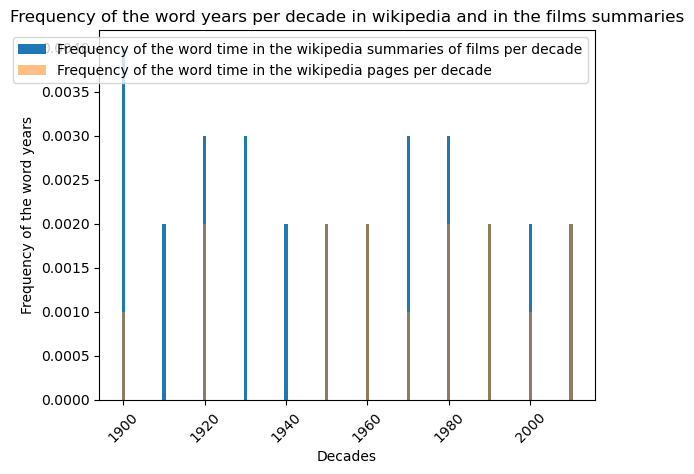

In [63]:
plt.bar(decade_name,wf_summarieswiki_filtered['time'], label = 'Frequency of the word time in the wikipedia summaries of films per decade')
plt.bar(decade_name,wf_wikipedia_filtered['time'], alpha = 0.5 ,label = 'Frequency of the word time in the wikipedia pages per decade')
plt.xlabel('Decades')
plt.ylabel('Frequency of the word years')
plt.title('Frequency of the word years per decade in wikipedia and in the films summaries')
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [64]:
correlation, p_value = pearsonr(wf_summarieswiki_filtered['time'], wf_wikipedia_filtered['time'])
p_value

0.8099560066499958

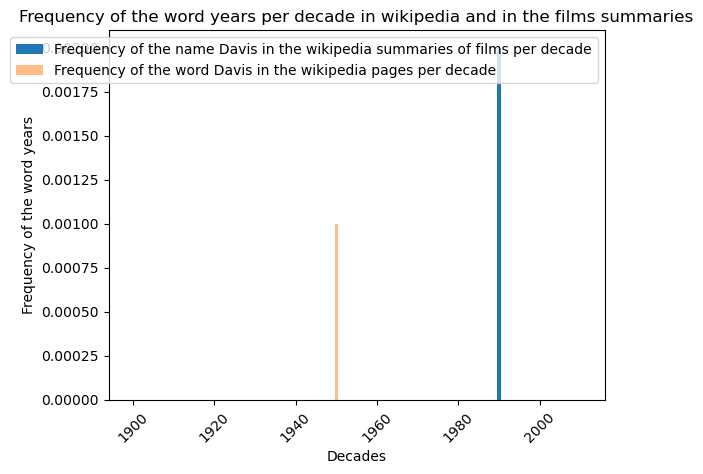

In [79]:
plt.bar(decade_name,wf_summarieswiki_filtered['Davis'], label = 'Frequency of the name Davis in the wikipedia summaries of films per decade')
plt.bar(decade_name,wf_wikipedia_filtered['Davis'], alpha = 0.5 ,label = 'Frequency of the word Davis in the wikipedia pages per decade')
plt.xlabel('Decades')
plt.ylabel('Frequency of the word years')
plt.title('Frequency of the word years per decade in wikipedia and in the films summaries')
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [80]:
correlation, p_value = pearsonr(wf_summarieswiki_filtered['Davis'], wf_wikipedia_filtered['Davis'])
p_value

0.778725396245442

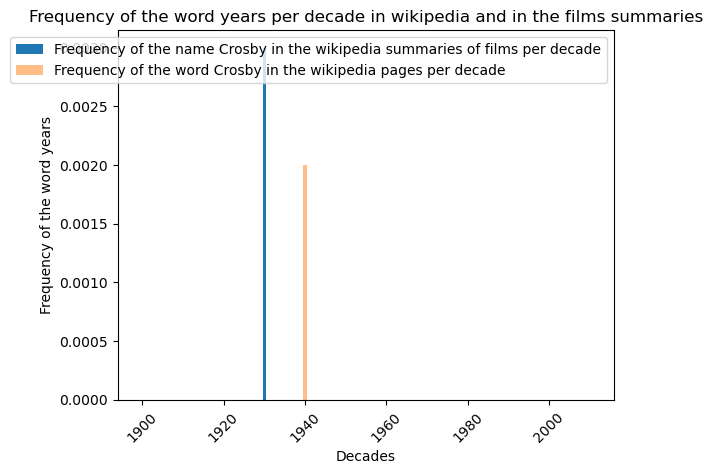

In [81]:
plt.bar(decade_name,wf_summarieswiki_filtered['Crosby'], label = 'Frequency of the name Crosby in the wikipedia summaries of films per decade')
plt.bar(decade_name,wf_wikipedia_filtered['Crosby'], alpha = 0.5 ,label = 'Frequency of the word Crosby in the wikipedia pages per decade')
plt.xlabel('Decades')
plt.ylabel('Frequency of the word years')
plt.title('Frequency of the word years per decade in wikipedia and in the films summaries')
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [82]:
correlation, p_value = pearsonr(wf_summarieswiki_filtered['Crosby'], wf_wikipedia_filtered['Crosby'])
p_value

0.778725396245442

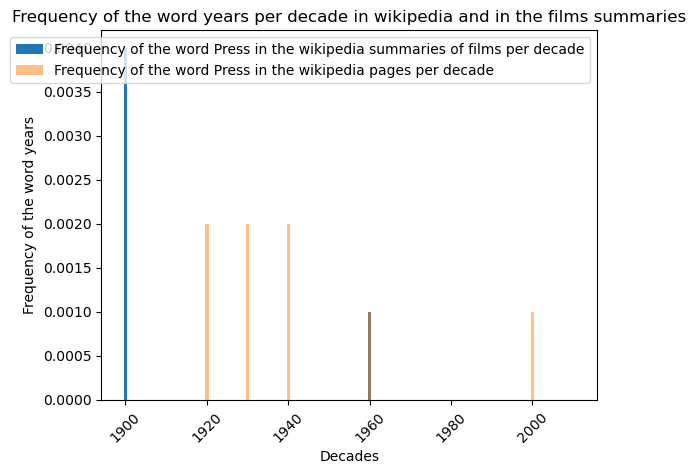

In [83]:
plt.bar(decade_name,wf_summarieswiki_filtered['Press'], label = 'Frequency of the word Press in the wikipedia summaries of films per decade')
plt.bar(decade_name,wf_wikipedia_filtered['Press'], alpha = 0.5 ,label = 'Frequency of the word Press in the wikipedia pages per decade')
plt.xlabel('Decades')
plt.ylabel('Frequency of the word years')
plt.title('Frequency of the word years per decade in wikipedia and in the films summaries')
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [84]:
correlation, p_value = pearsonr(wf_summarieswiki_filtered['Press'], wf_wikipedia_filtered['Press'])
p_value

0.5222770796988241

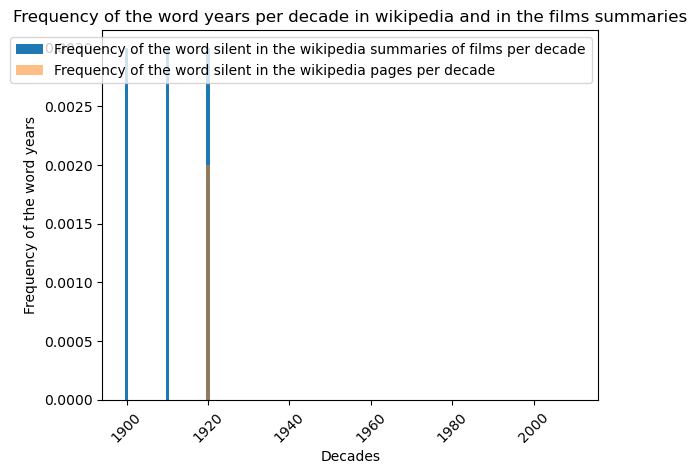

In [87]:
plt.bar(decade_name,wf_summarieswiki_filtered['silent'], label = 'Frequency of the word silent in the wikipedia summaries of films per decade')
plt.bar(decade_name,wf_wikipedia_filtered['silent'], alpha = 0.5 ,label = 'Frequency of the word silent in the wikipedia pages per decade')
plt.xlabel('Decades')
plt.ylabel('Frequency of the word years')
plt.title('Frequency of the word years per decade in wikipedia and in the films summaries')
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [88]:
correlation, p_value = pearsonr(wf_summarieswiki_filtered['silent'], wf_wikipedia_filtered['silent'])
p_value

0.08155339870160579

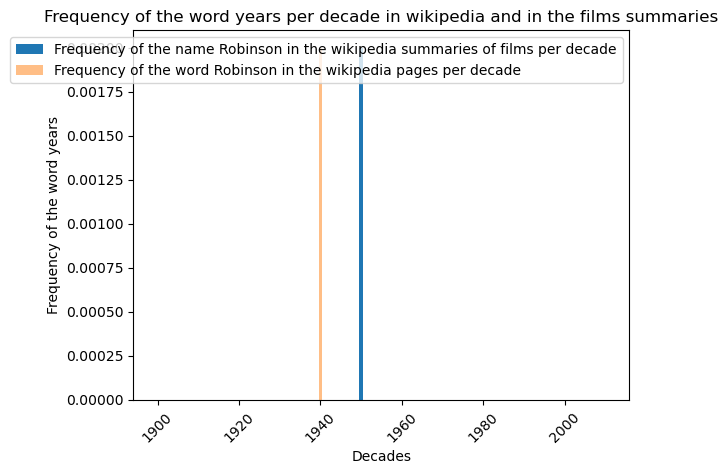

In [89]:
plt.bar(decade_name,wf_summarieswiki_filtered['Robinson'], label = 'Frequency of the name Robinson in the wikipedia summaries of films per decade')
plt.bar(decade_name,wf_wikipedia_filtered['Robinson'], alpha = 0.5 ,label = 'Frequency of the word Robinson in the wikipedia pages per decade')
plt.xlabel('Decades')
plt.ylabel('Frequency of the word years')
plt.title('Frequency of the word years per decade in wikipedia and in the films summaries')
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [90]:
correlation, p_value = pearsonr(wf_summarieswiki_filtered['Robinson'], wf_wikipedia_filtered['Robinson'])
p_value

0.778725396245442

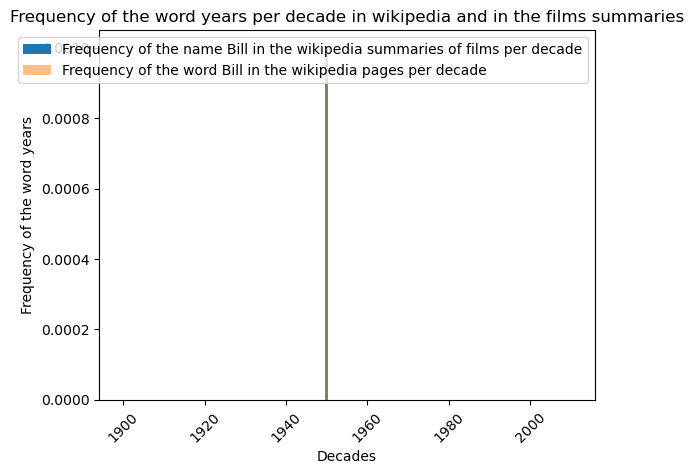

In [91]:
plt.bar(decade_name,wf_summarieswiki_filtered['Bill'], label = 'Frequency of the name Bill in the wikipedia summaries of films per decade')
plt.bar(decade_name,wf_wikipedia_filtered['Bill'], alpha = 0.5 ,label = 'Frequency of the word Bill in the wikipedia pages per decade')
plt.xlabel('Decades')
plt.ylabel('Frequency of the word years')
plt.title('Frequency of the word years per decade in wikipedia and in the films summaries')
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [92]:
correlation, p_value = pearsonr(wf_summarieswiki_filtered['Bill'], wf_wikipedia_filtered['Bill'])
p_value

0.0

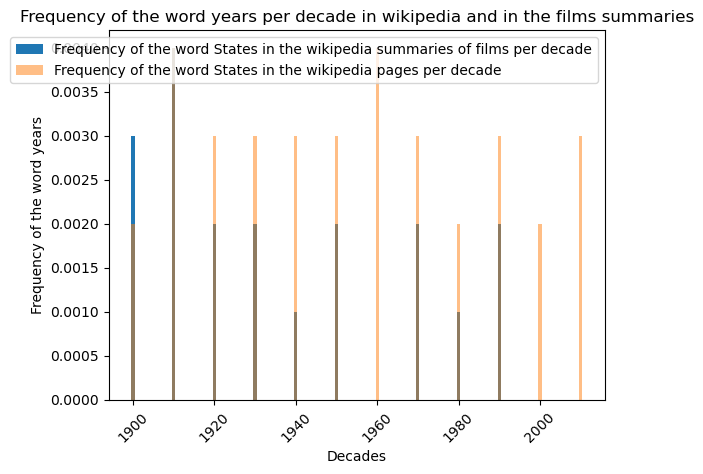

In [93]:
plt.bar(decade_name,wf_summarieswiki_filtered['States'], label = 'Frequency of the word States in the wikipedia summaries of films per decade')
plt.bar(decade_name,wf_wikipedia_filtered['States'], alpha = 0.5 ,label = 'Frequency of the word States in the wikipedia pages per decade')
plt.xlabel('Decades')
plt.ylabel('Frequency of the word years')
plt.title('Frequency of the word years per decade in wikipedia and in the films summaries')
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [94]:
correlation, p_value = pearsonr(wf_summarieswiki_filtered['States'], wf_wikipedia_filtered['States'])
p_value

0.589463053943445